<a href="https://colab.research.google.com/github/TejasKayarkar03/Machine-Vision-CM45/blob/main/MV_CM23045_Pr5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install opencv-python matplotlib kagglehub

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from google.colab.patches import cv2_imshow

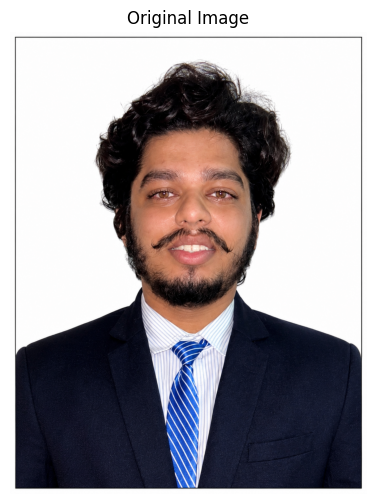

In [48]:
import cv2
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

In [49]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

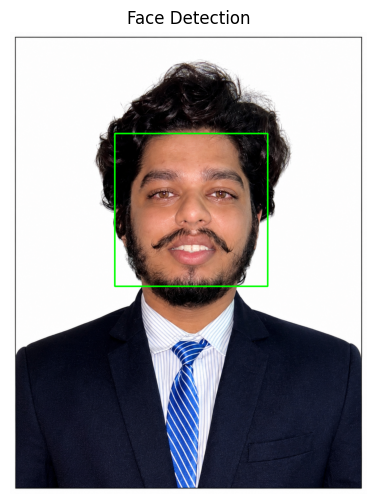

In [50]:
face_img = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5
)

for (x,y,w,h) in faces:
    cv2.rectangle(face_img,(x,y),(x+w,y+h),(0,255,0),3)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
plt.title("Face Detection")
plt.axis("off")
plt.show()

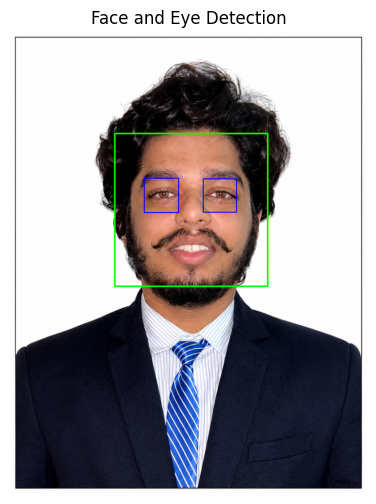

In [55]:
eye_img = img.copy()

for (x,y,w,h) in faces:

    # Draw face rectangle (Green)
    cv2.rectangle(
        eye_img,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        3
    )

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = eye_img[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (ex,ey,ew,eh) in eyes:

        # Draw eye rectangle (Blue)
        cv2.rectangle(
            roi_color,
            (ex,ey),
            (ex+ew,ey+eh),
            (255,0,0),
            2
        )

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB))
plt.title("Face and Eye Detection")
plt.axis("off")
plt.show()

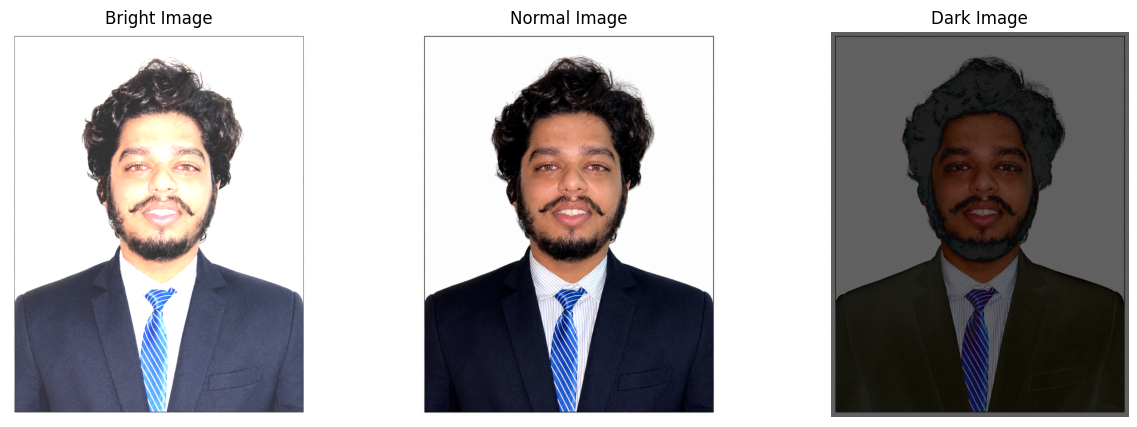

In [52]:
bright = cv2.convertScaleAbs(img, alpha=1.4, beta=50)

dark = cv2.convertScaleAbs(img, alpha=0.5, beta=-30)

fig,ax = plt.subplots(1,3,figsize=(15,5))

ax[0].imshow(cv2.cvtColor(bright,cv2.COLOR_BGR2RGB))
ax[0].set_title("Bright Image")

ax[1].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
ax[1].set_title("Normal Image")

ax[2].imshow(cv2.cvtColor(dark,cv2.COLOR_BGR2RGB))
ax[2].set_title("Dark Image")

for a in ax:
    a.axis("off")

plt.show()